In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
n = 1000

event_types = ["view", "cart", "purchase"]
products = ["mobile", "laptop", "tablet", "headphones"]
channels = ["Facebook Ads", "Google Ads", "Organic", "Email"]

data = {
    "user_id": np.random.randint(1000, 2000, n),
    "event_type": np.random.choice(event_types, n, p=[0.6, 0.25, 0.15]),
    "product": np.random.choice(products, n),
    "price": np.random.randint(5000, 80000, n),
    "channel": np.random.choice(channels, n),
    "event_time": pd.date_range(start="2024-01-01", periods=n, freq="min")
}

df = pd.DataFrame(data)

df.to_csv("dataset.csv", index=False)

df.head()


,user_id,event_type,product,price,channel,event_time
0,1652,cart,headphones,70428,Facebook Ads,2024-01-01 00:00:00
1,1153,cart,tablet,79150,Facebook Ads,2024-01-01 00:01:00
2,1244,cart,laptop,47863,Facebook Ads,2024-01-01 00:02:00
3,1916,purchase,mobile,37255,Facebook Ads,2024-01-01 00:03:00
4,1129,view,tablet,41517,Google Ads,2024-01-01 00:04:00


In [3]:
df = pd.read_csv("dataset.csv")

df = df.dropna()
df = df.drop_duplicates()

print(df.shape)
df.head()

(1000, 6)


,user_id,event_type,product,price,channel,event_time
0,1652,cart,headphones,70428,Facebook Ads,2024-01-01 00:00:00
1,1153,cart,tablet,79150,Facebook Ads,2024-01-01 00:01:00
2,1244,cart,laptop,47863,Facebook Ads,2024-01-01 00:02:00
3,1916,purchase,mobile,37255,Facebook Ads,2024-01-01 00:03:00
4,1129,view,tablet,41517,Google Ads,2024-01-01 00:04:00


In [4]:
funnel = df["event_type"].value_counts()

views = funnel.get("view", 0)
carts = funnel.get("cart", 0)
purchases = funnel.get("purchase", 0)

print("Views:", views)
print("Carts:", carts)
print("Purchases:", purchases)

Views: 579
Carts: 254
Purchases: 167


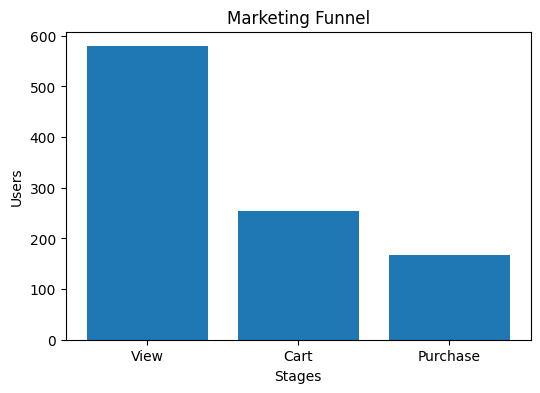

In [5]:
plt.figure(figsize=(6,4))

stages = ["View", "Cart", "Purchase"]
values = [views, carts, purchases]

plt.bar(stages, values)
plt.title("Marketing Funnel")
plt.xlabel("Stages")
plt.ylabel("Users")

plt.show()

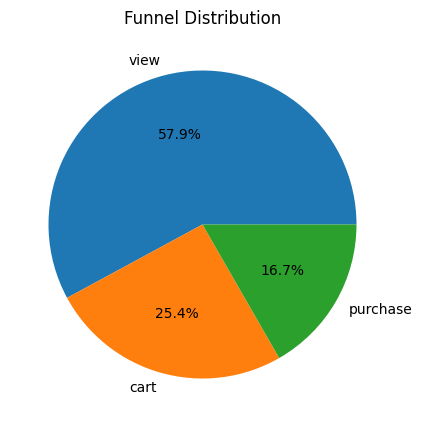

In [6]:
plt.figure(figsize=(5,5))

labels = funnel.index
sizes = funnel.values

plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title("Funnel Distribution")

plt.show()

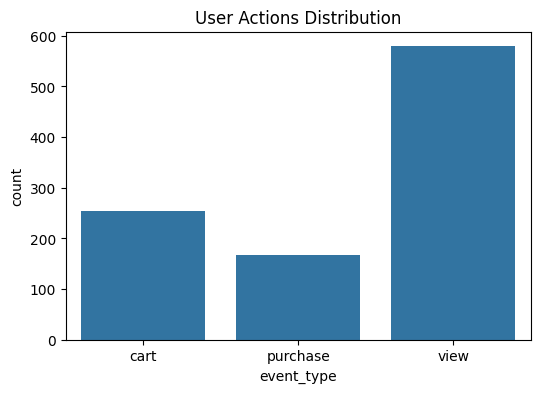

In [7]:
plt.figure(figsize=(6,4))

sns.countplot(x="event_type", data=df)
plt.title("User Actions Distribution")

plt.show()

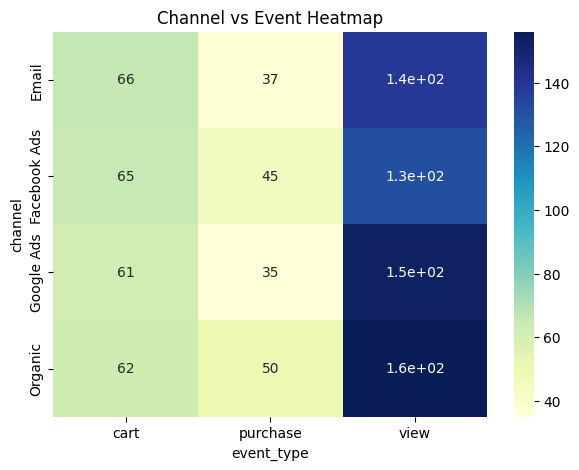

In [8]:
heatmap_data = df.groupby(["channel", "event_type"]).size().unstack()

plt.figure(figsize=(7,5))

sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu")

plt.title("Channel vs Event Heatmap")
plt.show()

In [9]:
view_to_cart = (carts / views) * 100 if views > 0 else 0
cart_to_purchase = (purchases / carts) * 100 if carts > 0 else 0

print("View → Cart:", round(view_to_cart, 2), "%")
print("Cart → Purchase:", round(cart_to_purchase, 2), "%")

View → Cart: 43.87 %
Cart → Purchase: 65.75 %


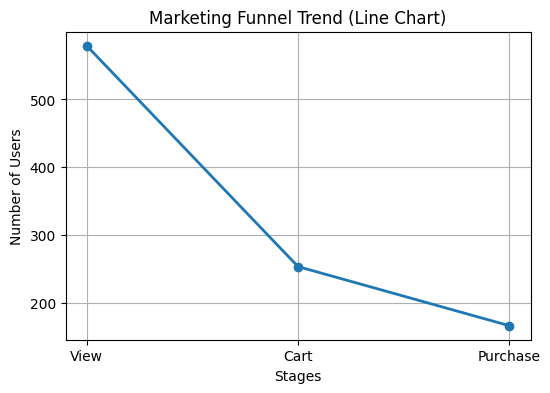

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

stages = ["View", "Cart", "Purchase"]
values = [views, carts, purchases]

plt.plot(stages, values, marker="o", linewidth=2)

plt.title("Marketing Funnel Trend (Line Chart)")
plt.xlabel("Stages")
plt.ylabel("Number of Users")
plt.grid(True)

plt.show()

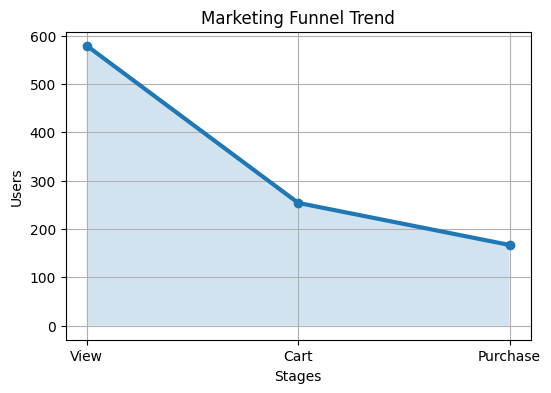

In [11]:
plt.figure(figsize=(6,4))

plt.plot(stages, values, marker="o", linewidth=3)
plt.fill_between(stages, values, alpha=0.2)

plt.title("Marketing Funnel Trend")
plt.xlabel("Stages")
plt.ylabel("Users")
plt.grid(True)

plt.show()

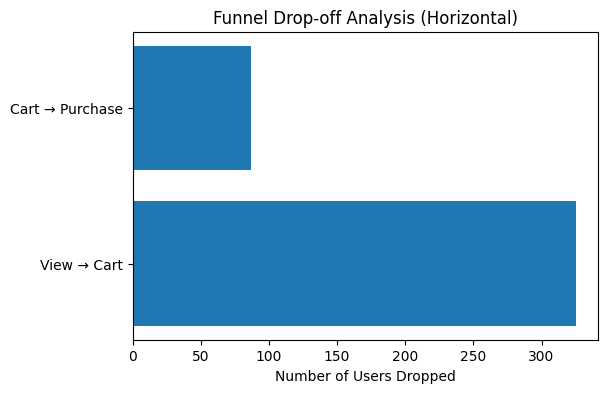

In [12]:
import matplotlib.pyplot as plt

# Drop calculations
drop_view_cart = views - carts
drop_cart_purchase = carts - purchases

stages = ["View → Cart", "Cart → Purchase"]
drops = [drop_view_cart, drop_cart_purchase]

plt.figure(figsize=(6,4))

plt.barh(stages, drops)

plt.title("Funnel Drop-off Analysis (Horizontal)")
plt.xlabel("Number of Users Dropped")

plt.show()

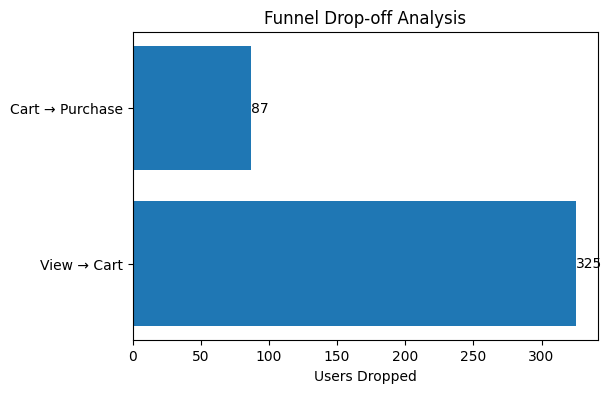

In [13]:
plt.figure(figsize=(6,4))

bars = plt.barh(stages, drops)

plt.title("Funnel Drop-off Analysis")
plt.xlabel("Users Dropped")

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
             int(bar.get_width()),
             va='center')

plt.show()